In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from torch.utils.data import Dataset, DataLoader, random_split
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, Callback
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
class conv_block(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(conv_block, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

In [3]:
class up_conv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(up_conv, self).__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.up(x)

In [ ]:
class UNet_3Plus(pl.LightningModule):
    def __init__(self, in_channels=3, out_classes=1, lr=3e-4):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        
        filters = [64, 128, 256, 512, 1024]
        
        # Encoder
        self.Conv1 = conv_block(in_channels, filters[0])
        self.Conv2 = conv_block(filters[0], filters[1])
        self.Conv3 = conv_block(filters[1], filters[2])
        self.Conv4 = conv_block(filters[2], filters[3])
        self.Conv5 = conv_block(filters[3], filters[4])
        self.pool = nn.MaxPool2d(2, 2)

        # Full-Scale Skip Connections (Decoder)
        self.cat_channels = 64
        self.UpChannels = self.cat_channels * 5 # 320 channels [cite: 652]

        # Decoder 4
        self.h1_PT_hd4 = nn.Sequential(nn.MaxPool2d(8, 8), nn.Conv2d(filters[0], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.h2_PT_hd4 = nn.Sequential(nn.MaxPool2d(4, 4), nn.Conv2d(filters[1], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.h3_PT_hd4 = nn.Sequential(nn.MaxPool2d(2, 2), nn.Conv2d(filters[2], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.h4_Cat_hd4 = nn.Sequential(nn.Conv2d(filters[3], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.hd5_UT_hd4 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), nn.Conv2d(filters[4], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.conv4d_1 = nn.Sequential(nn.Conv2d(self.UpChannels, self.UpChannels, 3, padding=1), nn.BatchNorm2d(self.UpChannels), nn.ReLU(inplace=True))

        # Decoder 3
        self.h1_PT_hd3 = nn.Sequential(nn.MaxPool2d(4, 4), nn.Conv2d(filters[0], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.h2_PT_hd3 = nn.Sequential(nn.MaxPool2d(2, 2), nn.Conv2d(filters[1], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.h3_Cat_hd3 = nn.Sequential(nn.Conv2d(filters[2], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.hd4_UT_hd3 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), nn.Conv2d(self.UpChannels, self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.hd5_UT_hd3 = nn.Sequential(nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True), nn.Conv2d(filters[4], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.conv3d_1 = nn.Sequential(nn.Conv2d(self.UpChannels, self.UpChannels, 3, padding=1), nn.BatchNorm2d(self.UpChannels), nn.ReLU(inplace=True))

        # Decoder 2
        self.h1_PT_hd2 = nn.Sequential(nn.MaxPool2d(2, 2), nn.Conv2d(filters[0], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.h2_Cat_hd2 = nn.Sequential(nn.Conv2d(filters[1], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.hd3_UT_hd2 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), nn.Conv2d(self.UpChannels, self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.hd4_UT_hd2 = nn.Sequential(nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True), nn.Conv2d(self.UpChannels, self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.hd5_UT_hd2 = nn.Sequential(nn.Upsample(scale_factor=8, mode='bilinear', align_corners=True), nn.Conv2d(filters[4], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.conv2d_1 = nn.Sequential(nn.Conv2d(self.UpChannels, self.UpChannels, 3, padding=1), nn.BatchNorm2d(self.UpChannels), nn.ReLU(inplace=True))

        # Decoder 1
        self.h1_Cat_hd1 = nn.Sequential(nn.Conv2d(filters[0], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.hd2_UT_hd1 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), nn.Conv2d(self.UpChannels, self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.hd3_UT_hd1 = nn.Sequential(nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True), nn.Conv2d(self.UpChannels, self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.hd4_UT_hd1 = nn.Sequential(nn.Upsample(scale_factor=8, mode='bilinear', align_corners=True), nn.Conv2d(self.UpChannels, self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.hd5_UT_hd1 = nn.Sequential(nn.Upsample(scale_factor=16, mode='bilinear', align_corners=True), nn.Conv2d(filters[4], self.cat_channels, 3, padding=1), nn.BatchNorm2d(self.cat_channels), nn.ReLU(inplace=True))
        self.conv1d_1 = nn.Sequential(nn.Conv2d(self.UpChannels, self.UpChannels, 3, padding=1), nn.BatchNorm2d(self.UpChannels), nn.ReLU(inplace=True))

        # Deep Supervision & CGM 
        self.out5 = nn.Conv2d(filters[4], out_classes, 3, padding=1)
        self.out4 = nn.Conv2d(self.UpChannels, out_classes, 3, padding=1)
        self.out3 = nn.Conv2d(self.UpChannels, out_classes, 3, padding=1)
        self.out2 = nn.Conv2d(self.UpChannels, out_classes, 3, padding=1)
        self.out1 = nn.Conv2d(self.UpChannels, out_classes, 3, padding=1)
        
        self.cgm_dropout = nn.Dropout(0.5)
        self.cgm_conv = nn.Conv2d(filters[4], 1, kernel_size=1)
        self.cgm_pool = nn.AdaptiveMaxPool2d(1)

        self.train_losses, self.val_losses = [], []

    def forward(self, x):
        # Encoder
        h1 = self.Conv1(x)
        h2 = self.Conv2(self.pool(h1))
        h3 = self.Conv3(self.pool(h2))
        h4 = self.Conv4(self.pool(h3))
        hd5 = self.Conv5(self.pool(h4))

        # CGM [cite: 730]
        cgm = self.cgm_dropout(hd5)
        cgm = self.cgm_conv(cgm)
        cgm = self.cgm_pool(cgm)
        cgm_out = torch.sigmoid(cgm).view(-1, 1, 1, 1)

        # Decoder 4
        h1_PT_hd4 = self.h1_PT_hd4(h1)
        h2_PT_hd4 = self.h2_PT_hd4(h2)
        h3_PT_hd4 = self.h3_PT_hd4(h3)
        h4_Cat_hd4 = self.h4_Cat_hd4(h4)
        hd5_UT_hd4 = self.hd5_UT_hd4(hd5)
        hd4 = self.conv4d_1(torch.cat((h1_PT_hd4, h2_PT_hd4, h3_PT_hd4, h4_Cat_hd4, hd5_UT_hd4), 1))

        # Decoder 3
        h1_PT_hd3 = self.h1_PT_hd3(h1)
        h2_PT_hd3 = self.h2_PT_hd3(h2)
        h3_Cat_hd3 = self.h3_Cat_hd3(h3)
        hd4_UT_hd3 = self.hd4_UT_hd3(hd4)
        hd5_UT_hd3 = self.hd5_UT_hd3(hd5)
        hd3 = self.conv3d_1(torch.cat((h1_PT_hd3, h2_PT_hd3, h3_Cat_hd3, hd4_UT_hd3, hd5_UT_hd3), 1))

        # Decoder 2
        h1_PT_hd2 = self.h1_PT_hd2(h1)
        h2_Cat_hd2 = self.h2_Cat_hd2(h2)
        hd3_UT_hd2 = self.hd3_UT_hd2(hd3)
        hd4_UT_hd2 = self.hd4_UT_hd2(hd4)
        hd5_UT_hd2 = self.hd5_UT_hd2(hd5)
        hd2 = self.conv2d_1(torch.cat((h1_PT_hd2, h2_Cat_hd2, hd3_UT_hd2, hd4_UT_hd2, hd5_UT_hd2), 1))

        # Decoder 1
        h1_Cat_hd1 = self.h1_Cat_hd1(h1)
        hd2_UT_hd1 = self.hd2_UT_hd1(hd2)
        hd3_UT_hd1 = self.hd3_UT_hd1(hd3)
        hd4_UT_hd1 = self.hd4_UT_hd1(hd4)
        hd5_UT_hd1 = self.hd5_UT_hd1(hd5)
        hd1 = self.conv1d_1(torch.cat((h1_Cat_hd1, hd2_UT_hd1, hd3_UT_hd1, hd4_UT_hd1, hd5_UT_hd1), 1))

        # Deep Supervision Side Outputs 
        d5 = self.out5(hd5) * cgm_out
        d5 = F.interpolate(d5, scale_factor=16, mode='bilinear', align_corners=True)
        d4 = self.out4(hd4) * cgm_out
        d4 = F.interpolate(d4, scale_factor=8, mode='bilinear', align_corners=True)
        d3 = self.out3(hd3) * cgm_out
        d3 = F.interpolate(d3, scale_factor=4, mode='bilinear', align_corners=True)
        d2 = self.out2(hd2) * cgm_out
        d2 = F.interpolate(d2, scale_factor=2, mode='bilinear', align_corners=True)
        d1 = self.out1(hd1) * cgm_out

        return [d1, d2, d3, d4, d5] if self.training else d1

    def hybrid_loss(self, pred, target):
        bce = F.binary_cross_entropy_with_logits(pred, target)
        p = torch.sigmoid(pred)
        dice = 1 - (2.*(p*target).sum() + 1e-7) / (p.sum() + target.sum() + 1e-7)
        iou = 1 - ((p*target).sum() + 1e-7) / ((p+target-p*target).sum() + 1e-7)
        return bce + dice + iou

    def training_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = sum([self.hybrid_loss(p, y) for p in preds]) # Combine loss from all 5 outputs
        self.log("train_loss", loss, prog_bar=True, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        self.train_losses.append(self.trainer.callback_metrics["train_loss"].item())

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x) # Only d1 during eval
        loss = self.hybrid_loss(y_hat, y)
        p = torch.sigmoid(y_hat)
        dice = (2.*((p>0.5)*y).sum() + 1e-7) / ((p>0.5).sum() + y.sum() + 1e-7)
        iou = ((p>0.5)*y).sum() / (((p>0.5) + y > 0).sum() + 1e-7)
        self.log_dict({"val_loss": loss, "val_dice": dice, "val_iou": iou}, prog_bar=True, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        if "val_loss" in self.trainer.callback_metrics:
            self.val_losses.append(self.trainer.callback_metrics["val_loss"].item())

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=30)
        return [opt], [sch]

In [5]:
class BrainDatasetUNet3Plus(Dataset):
    def __init__(self, imgs, masks, transform=None):
        self.imgs, self.masks, self.transform = imgs, masks, transform
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img = cv2.resize(cv2.cvtColor(cv2.imread(self.imgs[i]), cv2.COLOR_BGR2RGB), (256, 256))
        mask = cv2.resize(cv2.imread(self.masks[i], 0), (256, 256)) / 255.0
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']
        return img.float()/255., mask.unsqueeze(0).float()

In [7]:
class TextLoggerUNet3Plus(Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        m = trainer.callback_metrics
        with open("v7_unet3plus_log.txt", "a") as f:
            f.write(f"Epoch {trainer.current_epoch}: Loss {m.get('val_loss', 0):.4f} | "
                    f"Dice {m.get('val_dice', 0):.4f} | IoU {m.get('val_iou', 0):.4f}\n")

/home/linux-hasan/projects/envs/pt/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4070 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name        | Type   

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/linux-hasan/projects/envs/pt/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/linux-hasan/projects/envs/pt/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


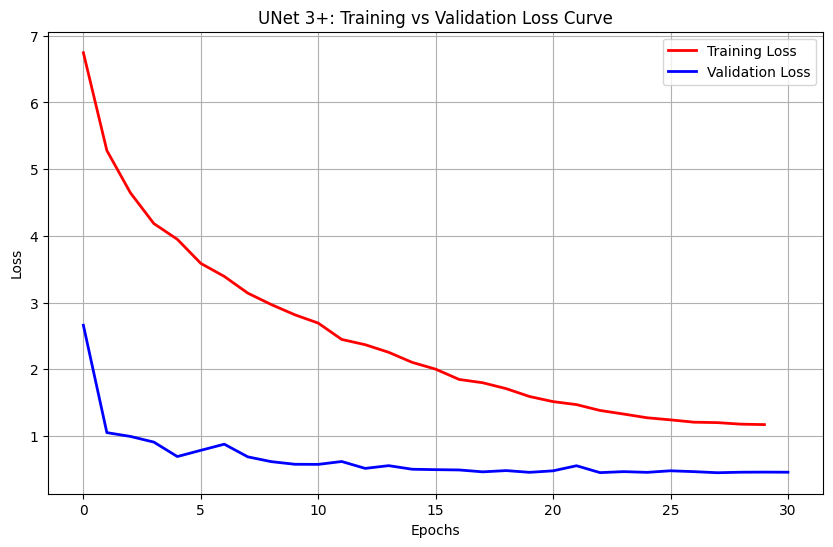

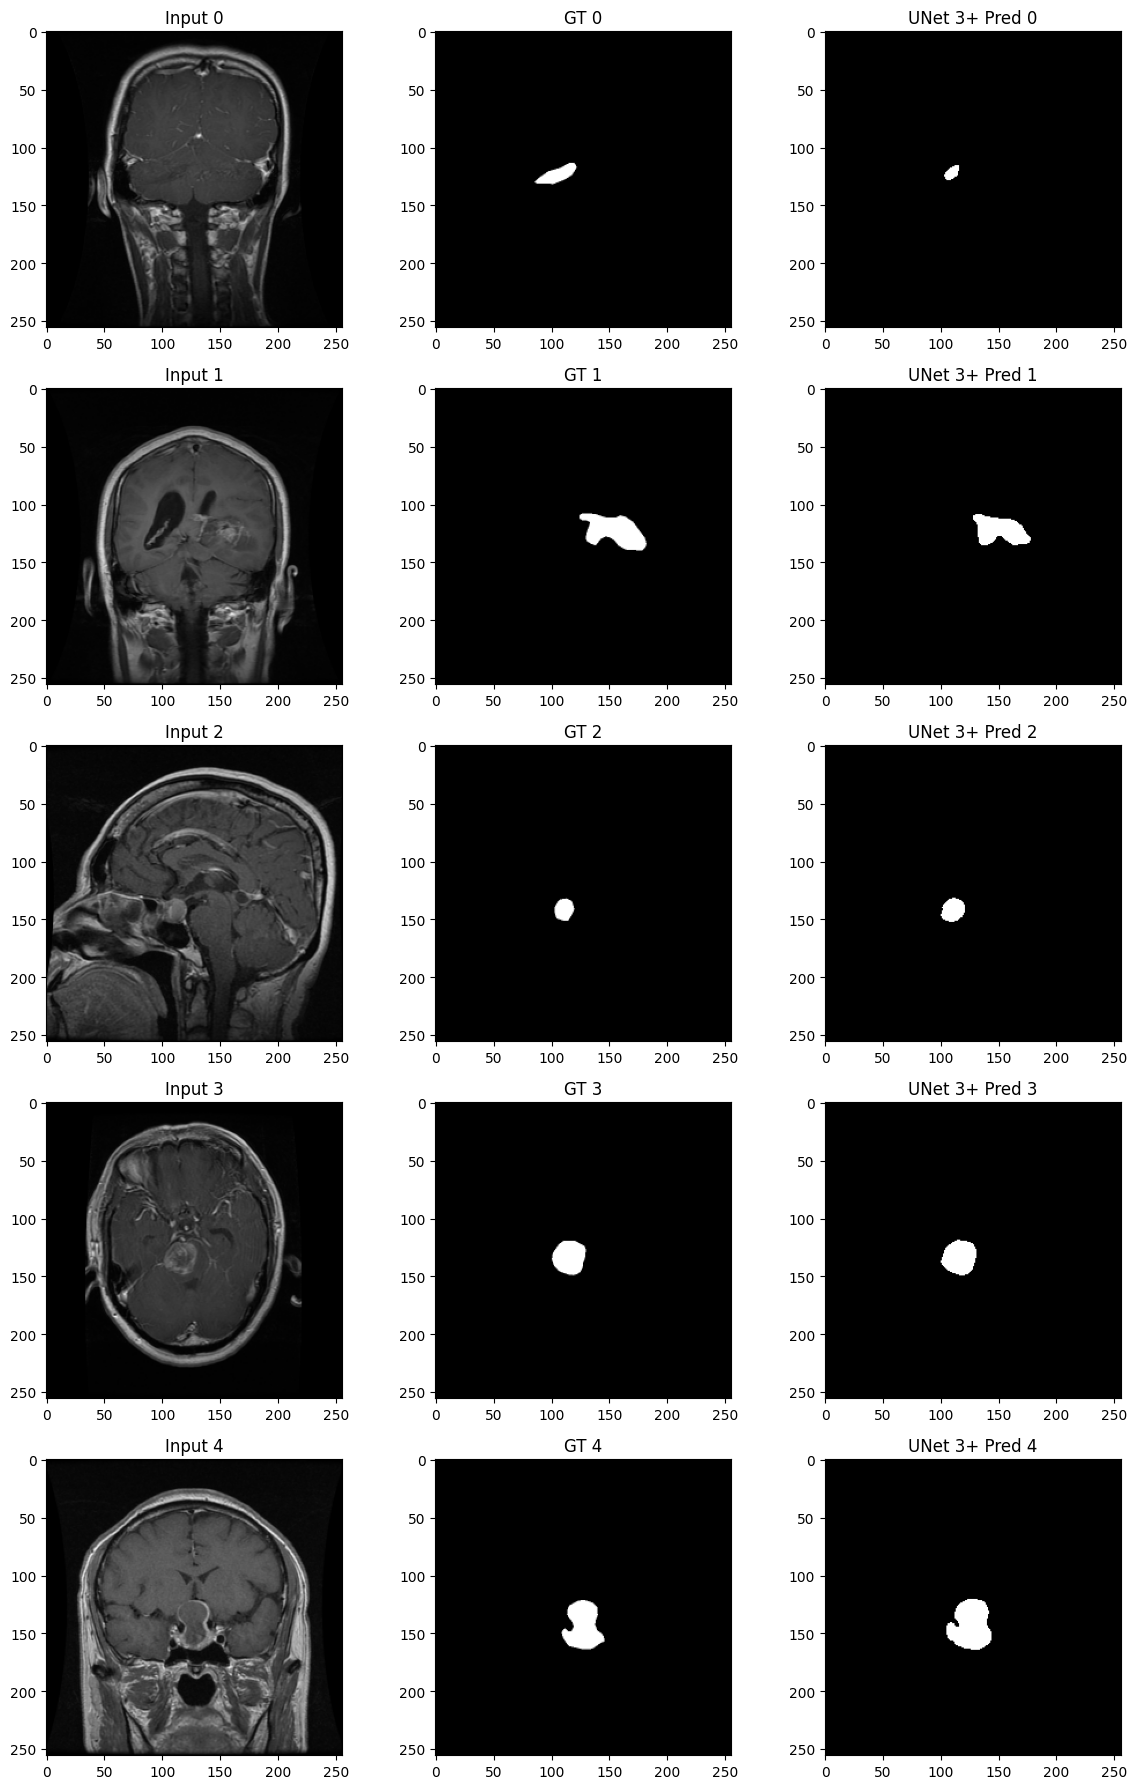

UNet 3+ Training Complete. Best model saved at: /home/linux-hasan/projects/samsung/lightning_logs/version_18/checkpoints/best_unet3plus.ckpt


In [8]:
def run_unet3plus_experiment():
    img_list = sorted(glob("dataset/images/*.png"))
    mask_list = sorted(glob("dataset/masks/*.png"))
    
    train_aug = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ElasticTransform(alpha=1, sigma=50, p=0.2),
        A.ShiftScaleRotate(shift_limit=0.1, rotate_limit=15, p=0.5),
        ToTensorV2()
    ])
    val_aug = A.Compose([ToTensorV2()])
    
    ds = BrainDatasetUNet3Plus(img_list, mask_list)
    train_idx, val_idx, test_idx = random_split(ds, [0.8, 0.1, 0.1])
    train_idx.dataset.transform = train_aug
    val_idx.dataset.transform = val_aug
    test_idx.dataset.transform = val_aug

    model = UNet_3Plus()
    checkpoint = ModelCheckpoint(monitor="val_dice", mode="max", save_top_k=1, filename="best_unet3plus")
    trainer = pl.Trainer(max_epochs=30, callbacks=[checkpoint, TextLoggerUNet3Plus()], accelerator="auto")
    
    # Train
    trainer.fit(model, DataLoader(train_idx, batch_size=4, shuffle=True), DataLoader(val_idx, batch_size=4))

    plt.figure(figsize=(10, 6))
    plt.plot(model.train_losses, color='red', label='Training Loss', linewidth=2)
    plt.plot(model.val_losses, color='blue', label='Validation Loss', linewidth=2)
    plt.title("UNet 3+: Training vs Validation Loss Curve")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
    plt.savefig("v7_unet3plus_loss_curve.png"); plt.show()

    best_model = UNet_3Plus.load_from_checkpoint(checkpoint.best_model_path).to("cpu").eval()
    fig, axes = plt.subplots(5, 3, figsize=(12, 18))
    for i in range(5):
        img, mask = test_idx[i]
        with torch.no_grad(): pred = torch.sigmoid(best_model(img.unsqueeze(0))) > 0.5
        axes[i,0].imshow(img.permute(1,2,0)); axes[i,0].set_title(f"Input {i}")
        axes[i,1].imshow(mask.squeeze(), cmap='gray'); axes[i,1].set_title(f"GT {i}")
        axes[i,2].imshow(pred.squeeze(), cmap='gray'); axes[i,2].set_title(f"UNet 3+ Pred {i}")
    plt.tight_layout(); plt.savefig("v7_unet3plus_results.png"); plt.show()
    print(f"UNet 3+ Training Complete. Best model saved at: {checkpoint.best_model_path}")

if __name__ == "__main__":
    run_unet3plus_experiment()